# Plot RL Part 1 results

In [20]:
from __future__ import annotations

from pathlib import Path

import re
import matplotlib.pyplot as plt
import pandas as pd

RESULTS_DIR = Path("results")
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

METHOD_ORDER = [
    "REINFORCE (baseline=0)",
    "REINFORCE (baseline=20)",
    "REINFORCE (baseline=50)",
    "REINFORCE (baseline=100)",
    "Actor-Critic one-step",
    "Actor-Critic n-step (n=10)",
]

FIGSIZE = (7.8, 4.6)
DPI = 300

print("Results dir:", RESULTS_DIR.resolve())
print("Plots dir:", PLOTS_DIR.resolve())

Results dir: /Users/matteosgobba/Documents/GitHub/rl-sim2real-hopper/p1-policy-gradient-methods/results
Plots dir: /Users/matteosgobba/Documents/GitHub/rl-sim2real-hopper/p1-policy-gradient-methods/plots


In [21]:
def style_axis(ax) -> None:
    ax.set_axisbelow(True)

    ax.grid(True, alpha=0.22, linewidth=0.8)
    ax.set_facecolor("white")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="both", labelsize=10)
    ax.xaxis.label.set_size(11)
    ax.yaxis.label.set_size(11)


def infer_label(row_or_name) -> str:
    if isinstance(row_or_name, str):
        run_name = row_or_name

        reinforce_match = re.match(
            r"reinforce_baseline_([0-9]+(?:\.[0-9]+)?)_seed_",
            run_name,
        )
        if reinforce_match:
            baseline = float(reinforce_match.group(1))
            return f"REINFORCE (baseline={baseline:g})"

        if run_name.startswith("actor_critic_nstep_10"):
            return "Actor-Critic n-step (n=10)"

        if run_name.startswith("actor_critic"):
            return "Actor-Critic one-step"

        return run_name

    algo = row_or_name.get("algo", "")
    baseline = row_or_name.get("baseline", "")
    run_name = row_or_name.get("run_name", "")

    if isinstance(run_name, str):
        reinforce_match = re.match(
            r"reinforce_baseline_([0-9]+(?:\.[0-9]+)?)_seed_",
            run_name,
        )
        if reinforce_match:
            baseline_value = float(reinforce_match.group(1))
            return f"REINFORCE (baseline={baseline_value:g})"

        if run_name.startswith("actor_critic_nstep_10"):
            return "Actor-Critic n-step (n=10)"

        if run_name.startswith("actor_critic"):
            return "Actor-Critic one-step"

    if algo == "reinforce":
        return f"REINFORCE (baseline={float(baseline):g})"

    if algo == "actor_critic":
        return "Actor-Critic"

    return str(algo)


def method_sort_key(method: str) -> int:
    if method in METHOD_ORDER:
        return METHOD_ORDER.index(method)
    return len(METHOD_ORDER)


def get_sorted_methods(df: pd.DataFrame) -> list[str]:
    return sorted(df["method"].dropna().unique(), key=method_sort_key)


def save_figure(fig: plt.Figure, output_stem: Path) -> None:
    png_path = output_stem.with_suffix(".png")
    pdf_path = output_stem.with_suffix(".pdf")

    fig.savefig(png_path, dpi=DPI, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")

In [22]:
def load_training_logs(results_dir: Path = RESULTS_DIR) -> pd.DataFrame:
    dfs = []

    for log_path in results_dir.glob("*/training_log.csv"):
        run_name = log_path.parent.name
        df = pd.read_csv(log_path)
        df["run_name"] = run_name
        df["method"] = infer_label(run_name)
        dfs.append(df)

    if not dfs:
        raise FileNotFoundError(
            f"No training_log.csv files found in {results_dir}/<run_name>/"
        )

    train_df = pd.concat(dfs, ignore_index=True)

    numeric_cols = [
        "episode",
        "episode_return",
        "episode_steps",
        "episode_time_sec",
        "elapsed_time_sec",
        "eval_mean_return",
        "eval_std_return",
        "loss",
        "policy_loss",
        "value_loss",
        "entropy",
        "mean_return",
        "mean_advantage",
        "advantage",
    ]

    for col in numeric_cols:
        if col in train_df.columns:
            train_df[col] = pd.to_numeric(train_df[col], errors="coerce")

    return train_df


def load_final_evaluations(results_dir: Path = RESULTS_DIR) -> pd.DataFrame:
    dfs = []

    for eval_path in results_dir.glob("*/final_evaluation.csv"):
        run_name = eval_path.parent.name
        df = pd.read_csv(eval_path)
        df["run_name"] = run_name
        df["method"] = df.apply(infer_label, axis=1)
        dfs.append(df)

    if not dfs:
        raise FileNotFoundError(
            f"No final_evaluation.csv files found in {results_dir}/<run_name>/"
        )

    final_df = pd.concat(dfs, ignore_index=True)

    final_numeric_cols = [
        "baseline",
        "seed",
        "episodes",
        "final_eval_episodes",
        "final_eval_mean_return",
        "final_eval_std_return",
        "total_training_time_sec",
    ]

    for col in final_numeric_cols:
        if col in final_df.columns:
            final_df[col] = pd.to_numeric(final_df[col], errors="coerce")

    return final_df


def add_moving_average(
    df: pd.DataFrame,
    value_col: str,
    window: int = 25,
) -> pd.DataFrame:
    df = df.copy()
    df[f"{value_col}_ma"] = (
        df.groupby("run_name")[value_col]
        .transform(lambda x: x.rolling(window=window, min_periods=1).mean())
    )
    return df


def aggregate_curve(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
    return (
        df.groupby(["method", x_col])[y_col]
        .agg(["mean", "std"])
        .reset_index()
    )


def build_summary(final_df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        final_df.groupby("method")
        .agg(
            mean_final_return=("final_eval_mean_return", "mean"),
            std_final_return=("final_eval_mean_return", "std"),
            mean_eval_std=("final_eval_std_return", "mean"),
            mean_training_time_sec=("total_training_time_sec", "mean"),
            std_training_time_sec=("total_training_time_sec", "std"),
            n_runs=("run_name", "count"),
        )
        .reset_index()
    )

    summary["std_final_return"] = summary["std_final_return"].fillna(0.0)
    summary["std_training_time_sec"] = summary["std_training_time_sec"].fillna(0.0)

    summary["sort_key"] = summary["method"].apply(method_sort_key)
    summary = summary.sort_values("sort_key").drop(columns=["sort_key"])

    return summary

## Load data

In [23]:
train_df = load_training_logs(RESULTS_DIR)
final_df = load_final_evaluations(RESULTS_DIR)
summary = build_summary(final_df)

summary_path = PLOTS_DIR / "summary_results.csv"
summary.to_csv(summary_path, index=False)

print("Training logs loaded:", train_df["run_name"].nunique(), "runs")
print("Final evaluations loaded:", final_df["run_name"].nunique(), "runs")
print(f"Saved summary: {summary_path}")

summary

Training logs loaded: 18 runs
Final evaluations loaded: 18 runs
Saved summary: plots/summary_results.csv


,method,mean_final_return,std_final_return,mean_eval_std,mean_training_time_sec,std_training_time_sec,n_runs
2,REINFORCE (baseline=0),20.775701,26.114613,2.475056,15.179614,16.300111,3
4,REINFORCE (baseline=20),175.191650,21.621955,3.726816,29.185815,4.337091,3
5,REINFORCE (baseline=50),155.870686,139.218333,22.082721,16.940511,13.859931,3
3,REINFORCE (baseline=100),31.766947,26.543797,2.288527,4.714785,2.769460,3
1,Actor-Critic one-step,48.175449,11.068634,2.206183,15.486248,2.270980,3
0,Actor-Critic n-step (n=10),574.767143,446.610396,1.553519,43.063996,18.172160,3


## Plot 1: Training return curves

Saved: plots/training_curves.png
Saved: plots/training_curves.pdf


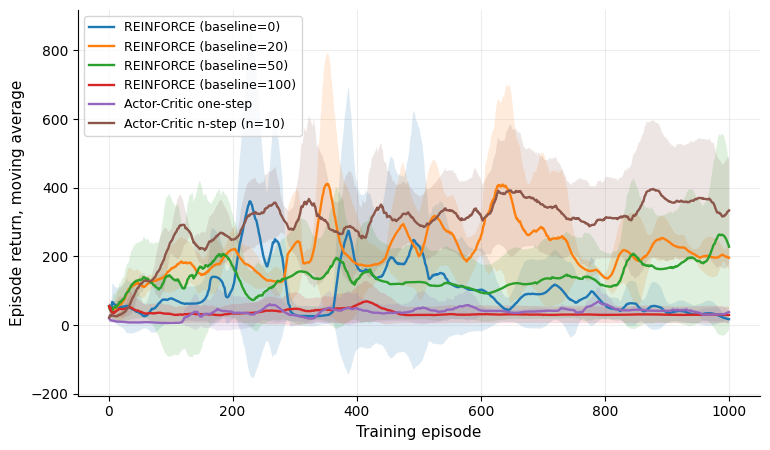

In [24]:
df = add_moving_average(train_df, "episode_return", window=25)
agg = aggregate_curve(df, "episode", "episode_return_ma")

fig, ax = plt.subplots(figsize=FIGSIZE)
fig.patch.set_facecolor("white")

for method in get_sorted_methods(agg):
    method_df = agg[agg["method"] == method].sort_values("episode")

    x = method_df["episode"]
    y = method_df["mean"]
    std = method_df["std"].fillna(0.0)

    ax.plot(
        x,
        y,
        label=method,
        linewidth=1.7,
    )
    ax.fill_between(
        x,
        y - std,
        y + std,
        alpha=0.15,
        linewidth=0,
    )

ax.set_xlabel("Training episode")
ax.set_ylabel("Episode return, moving average")

style_axis(ax)

ax.legend(
    frameon=True,
    fontsize=9,
    loc="best",
)

fig.tight_layout()

save_figure(fig, PLOTS_DIR / "training_curves")
plt.show()

## Plot 2: Evaluation return during training

Saved: plots/evaluation_curves.png
Saved: plots/evaluation_curves.pdf


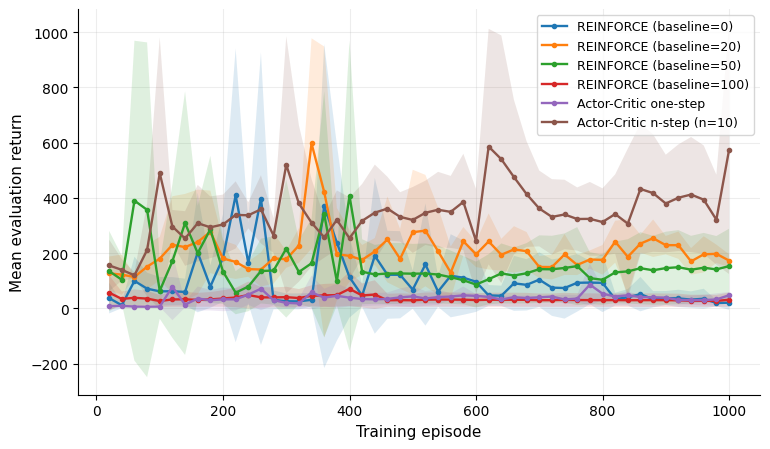

In [ ]:
df = train_df.dropna(subset=["eval_mean_return"]).copy()

if df.empty:
    print("No evaluation data found.")
else:
    agg = aggregate_curve(df, "episode", "eval_mean_return")

    fig, ax = plt.subplots(figsize=FIGSIZE)
    fig.patch.set_facecolor("white")

    for method in get_sorted_methods(agg):
        method_df = agg[agg["method"] == method].sort_values("episode")

        x = method_df["episode"]
        y = method_df["mean"]
        std = method_df["std"].fillna(0.0)

        ax.plot(
            x,
            y,
            marker="o",
            markersize=3,
            linewidth=1.7,
            label=method,
        )
        ax.fill_between(
            x,
            y - std,
            y + std,
            alpha=0.15,
            linewidth=0,
        )

    ax.set_xlabel("Training episode")
    ax.set_ylabel("Mean evaluation return")

    style_axis(ax)

    ax.legend(
        frameon=True,
        fontsize=9,
        loc="best",
    )

    fig.tight_layout()

    save_figure(fig, PLOTS_DIR / "evaluation_curves")
    plt.show()

## Plot 3: Final evaluation barplot

Saved: plots/final_eval_barplot.png
Saved: plots/final_eval_barplot.pdf


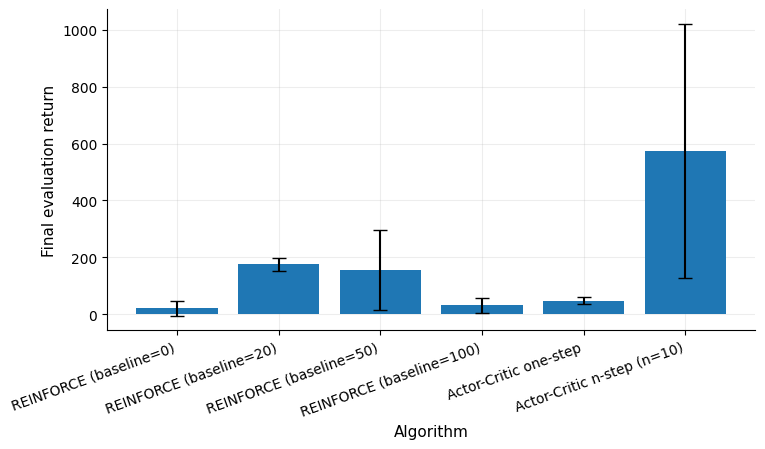

In [26]:
summary = build_summary(final_df)
summary.to_csv(PLOTS_DIR / "summary_results.csv", index=False)

fig, ax = plt.subplots(figsize=FIGSIZE)
fig.patch.set_facecolor("white")

bars = ax.bar(
    summary["method"],
    summary["mean_final_return"],
    yerr=summary["std_final_return"],
    capsize=5,
    zorder=3,
)

ax.set_xlabel("Algorithm")
ax.set_ylabel("Final evaluation return")

style_axis(ax)

ax.tick_params(axis="x", rotation=20)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

fig.tight_layout()

save_figure(fig, PLOTS_DIR / "final_eval_barplot")
plt.show()

## Plot 4: Training time barplot

Saved: plots/training_time_barplot.png
Saved: plots/training_time_barplot.pdf


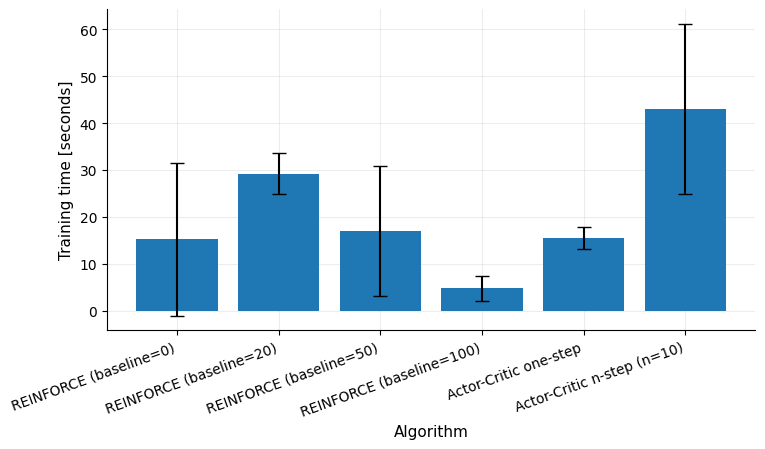

In [27]:
summary = build_summary(final_df)
summary.to_csv(PLOTS_DIR / "summary_results.csv", index=False)

fig, ax = plt.subplots(figsize=FIGSIZE)
fig.patch.set_facecolor("white")

bars = ax.bar(
    summary["method"],
    summary["mean_training_time_sec"],
    yerr=summary["std_training_time_sec"].fillna(0.0),
    capsize=5,
    zorder=3,
)

ax.set_xlabel("Algorithm")
ax.set_ylabel("Training time [seconds]")

style_axis(ax)

ax.tick_params(axis="x", rotation=20)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

fig.tight_layout()

save_figure(fig, PLOTS_DIR / "training_time_barplot")
plt.show()